<a href="https://colab.research.google.com/github/Melisaoktavia/tugas_minggu6/blob/main/PCD_MGG6_TGS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

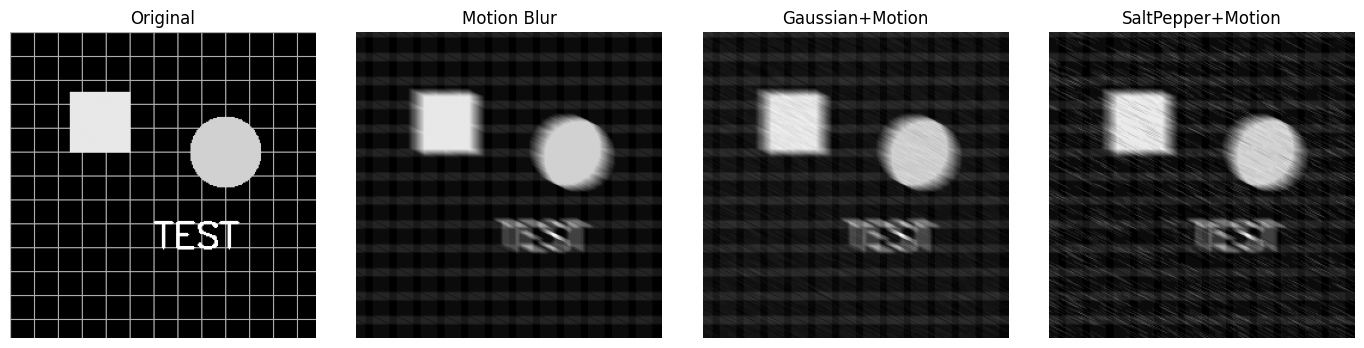


EVALUASI RESTORASI

Degradasi: Motion Blur
Inverse    | MSE:43976.71 | PSNR:1.70 dB | SSIM:0.073 | Time:0.009s
Wiener     | MSE:5372.75 | PSNR:10.83 dB | SSIM:0.381 | Time:0.010s
Lucy       | MSE:709.32 | PSNR:19.62 dB | SSIM:0.683 | Time:0.214s

Degradasi: Gaussian+Motion
Inverse    | MSE:54694.48 | PSNR:0.75 dB | SSIM:0.066 | Time:0.004s
Wiener     | MSE:5372.75 | PSNR:10.83 dB | SSIM:0.381 | Time:0.005s
Lucy       | MSE:1081.34 | PSNR:17.79 dB | SSIM:0.354 | Time:0.173s

Degradasi: SaltPepper+Motion
Inverse    | MSE:46756.28 | PSNR:1.43 dB | SSIM:0.070 | Time:0.004s
Wiener     | MSE:5372.75 | PSNR:10.83 dB | SSIM:0.381 | Time:0.006s
Lucy       | MSE:1445.18 | PSNR:16.53 dB | SSIM:0.359 | Time:0.177s


In [1]:
# ==============================
# IMPORT LIBRARY
# ==============================

import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from scipy import signal
from skimage.metrics import structural_similarity as ssim

# ==============================
# LOAD / BUAT CITRA ASLI
# ==============================

def create_original_image():
    img = np.zeros((256,256), dtype=np.uint8)

    # grid pattern
    for i in range(0,256,20):
        cv2.line(img,(i,0),(i,255),150,1)
        cv2.line(img,(0,i),(255,i),150,1)

    # object
    cv2.rectangle(img,(50,50),(100,100),200,-1)
    cv2.circle(img,(180,100),30,180,-1)

    cv2.putText(img,'TEST',(120,180),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,220,2)

    return img

# ==============================
# MOTION BLUR PSF
# ==============================

def motion_psf(length=15, angle=30):

    psf = np.zeros((length,length))
    center = length//2

    angle_rad = np.deg2rad(angle)

    x1 = int(center - (length/2)*np.cos(angle_rad))
    y1 = int(center - (length/2)*np.sin(angle_rad))
    x2 = int(center + (length/2)*np.cos(angle_rad))
    y2 = int(center + (length/2)*np.sin(angle_rad))

    cv2.line(psf,(x1,y1),(x2,y2),1,1)

    psf = psf/np.sum(psf)

    return psf

# ==============================
# DEGRADASI CITRA
# ==============================

def add_motion_blur(img, psf):

    blurred = cv2.filter2D(
        img.astype(float),
        -1,
        psf
    )

    return np.clip(blurred,0,255).astype(np.uint8)

def add_gaussian_noise(img, sigma=20):

    noise = np.random.normal(
        0,
        sigma,
        img.shape
    )

    noisy = img + noise

    return np.clip(noisy,0,255).astype(np.uint8)

def add_salt_pepper(img, amount=0.05):

    noisy = img.copy()

    num_salt = int(amount*img.size/2)
    num_pepper = int(amount*img.size/2)

    # salt
    coords = [
        np.random.randint(0,i,num_salt)
        for i in img.shape
    ]
    noisy[coords[0],coords[1]] = 255

    # pepper
    coords = [
        np.random.randint(0,i,num_pepper)
        for i in img.shape
    ]
    noisy[coords[0],coords[1]] = 0

    return noisy

# ==============================
# RESTORASI
# ==============================

def inverse_filter(image, psf, eps=1e-3):

    start = time.time()

    G = np.fft.fft2(image)

    psf_pad = np.zeros_like(image)
    psf_pad[:psf.shape[0],:psf.shape[1]] = psf

    psf_pad = np.fft.ifftshift(psf_pad)

    H = np.fft.fft2(psf_pad)

    F_hat = G/(H+eps)

    restored = np.abs(np.fft.ifft2(F_hat))

    end = time.time()

    return np.clip(restored,0,255).astype(np.uint8), end-start

def wiener_filter(image, psf, K=0.01):

    start = time.time()

    G = np.fft.fft2(image)

    psf_pad = np.zeros_like(image)
    psf_pad[:psf.shape[0],:psf.shape[1]] = psf

    psf_pad = np.fft.ifftshift(psf_pad)

    H = np.fft.fft2(psf_pad)

    H_conj = np.conj(H)

    W = H_conj/(np.abs(H)**2 + K)

    F_hat = G*W

    restored = np.abs(np.fft.ifft2(F_hat))

    end = time.time()

    return np.clip(restored,0,255).astype(np.uint8), end-start

def lucy_richardson(image, psf, iterations=20):

    start = time.time()

    image = image.astype(float)

    estimate = image.copy()

    psf_flip = np.flip(psf)

    for i in range(iterations):

        conv = cv2.filter2D(
            estimate,
            -1,
            psf
        )

        conv = np.where(conv==0,1e-8,conv)

        ratio = image/conv

        correction = cv2.filter2D(
            ratio,
            -1,
            psf_flip
        )

        estimate *= correction

    end = time.time()

    return np.clip(estimate,0,255).astype(np.uint8), end-start

# ==============================
# METRIK EVALUASI
# ==============================

def evaluate(original, restored):

    mse = np.mean(
        (original.astype(float)
         - restored.astype(float))**2
    )

    psnr = 10*np.log10(255**2/mse)

    ssim_val = ssim(
        original,
        restored,
        data_range=255
    )

    return mse, psnr, ssim_val

# ==============================
# MAIN PIPELINE
# ==============================

original = create_original_image()

psf = motion_psf(
    length=15,
    angle=30
)

# Degradasi

motion_only = add_motion_blur(
    original,
    psf
)

gaussian_motion = add_motion_blur(
    add_gaussian_noise(original,20),
    psf
)

sp_motion = add_motion_blur(
    add_salt_pepper(original,0.05),
    psf
)

degraded_images = {
    "Motion Blur": motion_only,
    "Gaussian+Motion": gaussian_motion,
    "SaltPepper+Motion": sp_motion
}

# ==============================
# RESTORASI + EVALUASI
# ==============================

results = {}

for name, img in degraded_images.items():

    inv_img, t1 = inverse_filter(img, psf)

    wien_img, t2 = wiener_filter(img, psf)

    lucy_img, t3 = lucy_richardson(img, psf)

    results[name] = {
        "Inverse": (inv_img,t1),
        "Wiener": (wien_img,t2),
        "Lucy": (lucy_img,t3)
    }

# ==============================
# TAMPILKAN HASIL
# ==============================

plt.figure(figsize=(14,10))

plt.subplot(3,4,1)
plt.imshow(original,cmap='gray')
plt.title("Original")
plt.axis('off')

idx = 2

for name,img in degraded_images.items():

    plt.subplot(3,4,idx)
    plt.imshow(img,cmap='gray')
    plt.title(name)
    plt.axis('off')

    idx+=1

plt.tight_layout()
plt.show()

# ==============================
# PRINT EVALUASI
# ==============================

print("\nEVALUASI RESTORASI")
print("="*60)

for deg_name in results:

    print("\nDegradasi:",deg_name)

    for method in results[deg_name]:

        restored, t = results[deg_name][method]

        mse, psnr, ssim_val = evaluate(
            original,
            restored
        )

        print(
            f"{method:10} | "
            f"MSE:{mse:.2f} | "
            f"PSNR:{psnr:.2f} dB | "
            f"SSIM:{ssim_val:.3f} | "
            f"Time:{t:.3f}s"
        )